## Main Setup

In [1]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:


evaluation_methods = {
    "deletion": "Deletion",
    "insertion": "Insertion",
    "negative": "Negative Perturbation",
}

replacement_strategies = {
    "black-5": "Black masking", 
    "minimum-intensity": "Minimum intensity",
    "white-5": "White masking", 
    "gaussian_blur": "Gaussian Blur",
    "attention_mask" : "Attention Mask",  
}

xai_methods = {
    "gradcam": "Grad-CAM",
    "last_layer": "Last-layer attention", 
    "slice_weighted_rollout": "Attention rollout" 
}

colors = {
    "gradcam": "#1f77b4",              # blue
    "last_layer": "#ff7f0e",           # orange
    "slice_weighted_rollout": "#2ca02c"  # green
}

In [3]:
base_path = Path("/home/jovyan/work/MST/results/DINOv3ViTB/evaluation_results")

In [4]:
test_data = np.load("/home/jovyan/work/MST/results/DINOv3ViTB/evaluation_results/deletion/deletion_curves/gradcam/attention_mask/02F4A1FB_left_curve_attention_mask.npy", allow_pickle=True).item()

In [5]:
test_data.keys()

dict_keys(['percentages', 'raw_logits', 'confidences', 'normalized_confidences', 'predicted_class', 'predicted_confidences', 'predicted_normalized_confidences', 'auc', 'replacement'])

## Mean Average

### Deletion
Method Comparison, single strategy

#### One Strategy
Black Masking

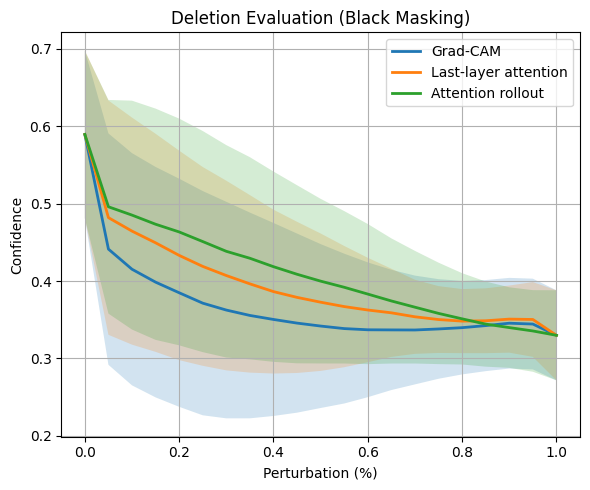

In [6]:
evaluation_metric = "deletion"
strategy = "black-5"  # first graph should use ONE strategy

# ===== PLOT =====
plt.figure(figsize=(6,5))

for method_key, method_name in xai_methods.items():

    curve_dir = base_path / evaluation_metric / f"{evaluation_metric}_curves" / method_key / strategy

    curves = []
    percentages = None

    for f in curve_dir.glob("*.npy"):
        data = np.load(f, allow_pickle=True).item()
        curves.append(data["predicted_confidences"])

        if percentages is None:
            percentages = data["percentages"]

    if len(curves) == 0:
        continue

    curves = np.array(curves)

    # ===== MEAN CURVE =====
    mean_curve = curves.mean(axis=0)

    # ===== OPTIONAL: STD =====
    std_curve = curves.std(axis=0)

    # ===== PLOT =====
    # plt.plot(percentages, mean_curve, label=method_name)
    plt.plot(percentages,
             mean_curve,
             label=method_name,
             color=colors[method_key],
             linewidth=2)
    plt.fill_between(percentages, mean_curve - std_curve, mean_curve + std_curve, alpha=0.2)

# ===== STYLE =====
plt.xlabel("Perturbation (%)")
plt.ylabel("Confidence")
plt.title("Deletion Evaluation (Black Masking)")
plt.legend()
plt.grid(True)
# plt.ylim(0, 1)

plt.tight_layout()
plt.show()

#### Strategies per graph

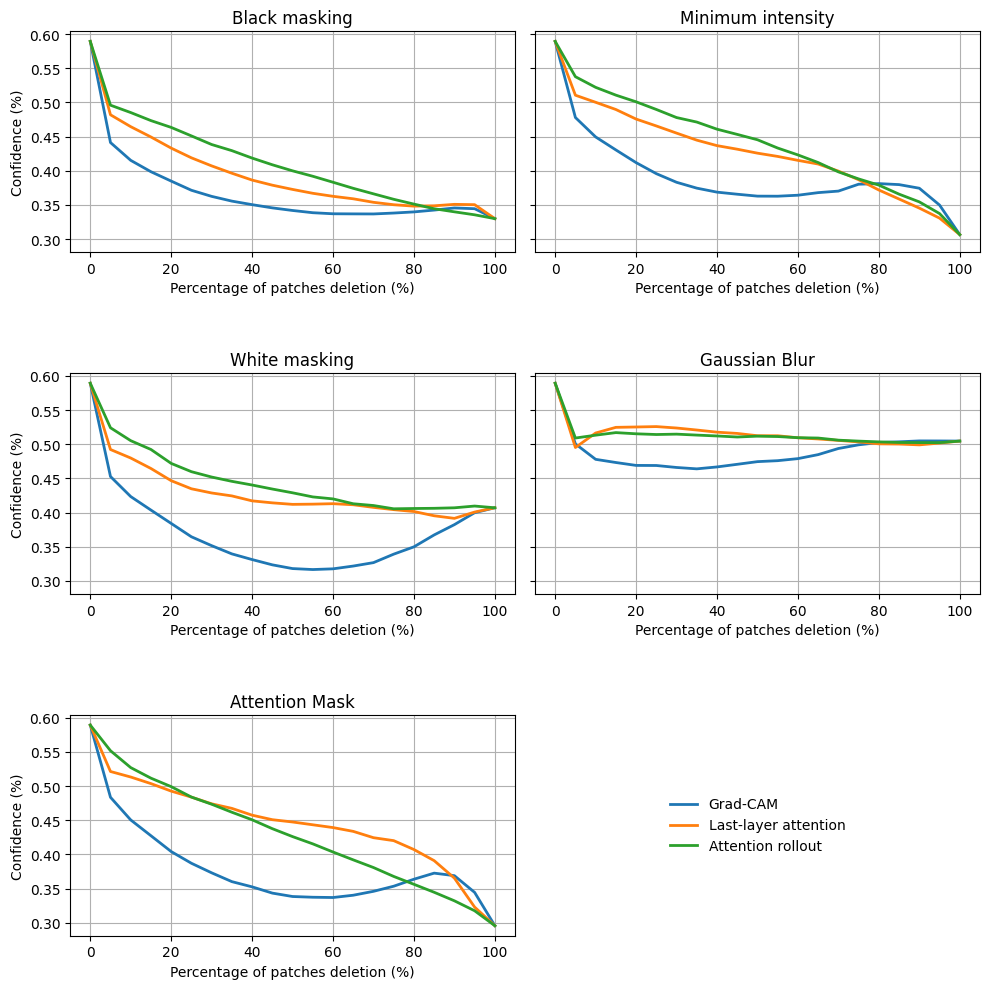

In [7]:
evaluation_metric = "deletion"
OUTPUT_DIR = Path("perturbation_plots")
OUTPUT_DIR.mkdir(exist_ok=True)

# ===== SETUP =====
strategies = list(replacement_strategies.items())
n_strategies = len(strategies)

# Create 3 rows, 2 columns
fig, axes = plt.subplots(3, 2, figsize=(10, 10), sharey=True)

# Flatten axes for easy indexing
axes = axes.flatten()

# ===== LOOP =====
for i, (strategy_key, strategy_name) in enumerate(strategies):
    ax = axes[i]

    for method_key, method_name in xai_methods.items():

        curve_dir = base_path / evaluation_metric / f"{evaluation_metric}_curves" / method_key / strategy_key

        curves = []
        percentages = None

        for f in curve_dir.glob("*.npy"):
            data = np.load(f, allow_pickle=True).item()
            curves.append(data["predicted_confidences"])

            if percentages is None:
                percentages = data["percentages"]

        if len(curves) == 0:
            continue

        curves = np.array(curves)

        # Mean curve
        mean_curve = curves.mean(axis=0)

        ax.plot(percentages*100,
                mean_curve,
                label=method_name,
                color=colors[method_key],
                linewidth=2)
        
        # std_curve = curves.std(axis=0)

        # ax.fill_between(
        #     percentages*100,
        #     mean_curve - std_curve,
        #     mean_curve + std_curve,
        #     color=colors[method_key],
        #     alpha=0.2
        # )

    # Subplot formatting
    ax.set_title(strategy_name)
    ax.set_xlabel(f"Percentage of patches {evaluation_metric} (%)")
    ax.grid(True)

# # ===== REMOVE EMPTY PLOT =====
# for j in range(n_strategies, len(axes)):
#     fig.delaxes(axes[j])

# ===== USE LAST AXIS FOR LEGEND =====
legend_ax = axes[-1]
# Turn off axis
legend_ax.axis("off")
# Get legend handles
handles, labels = axes[0].get_legend_handles_labels()
# Place legend inside this subplot
legend_ax.legend(handles, labels, loc="center", frameon=False)

# ===== SHARED LABEL =====
axes[0].set_ylabel("Confidence (%)")
axes[2].set_ylabel("Confidence (%)")
axes[4].set_ylabel("Confidence (%)")

# # ===== LEGEND =====
# handles, labels = axes[0].get_legend_handles_labels()
# fig.legend(handles, labels, loc="lower right", ncol=3)

# ===== TITLE =====
# fig.suptitle(f"{evaluation_methods[evaluation_metric]} Evaluation (Mean Curves)", fontsize=14)

# plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.tight_layout(h_pad=4)
# plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"{evaluation_metric}_evaluation_curves.jpg", dpi=150)
plt.show()

### Insertion

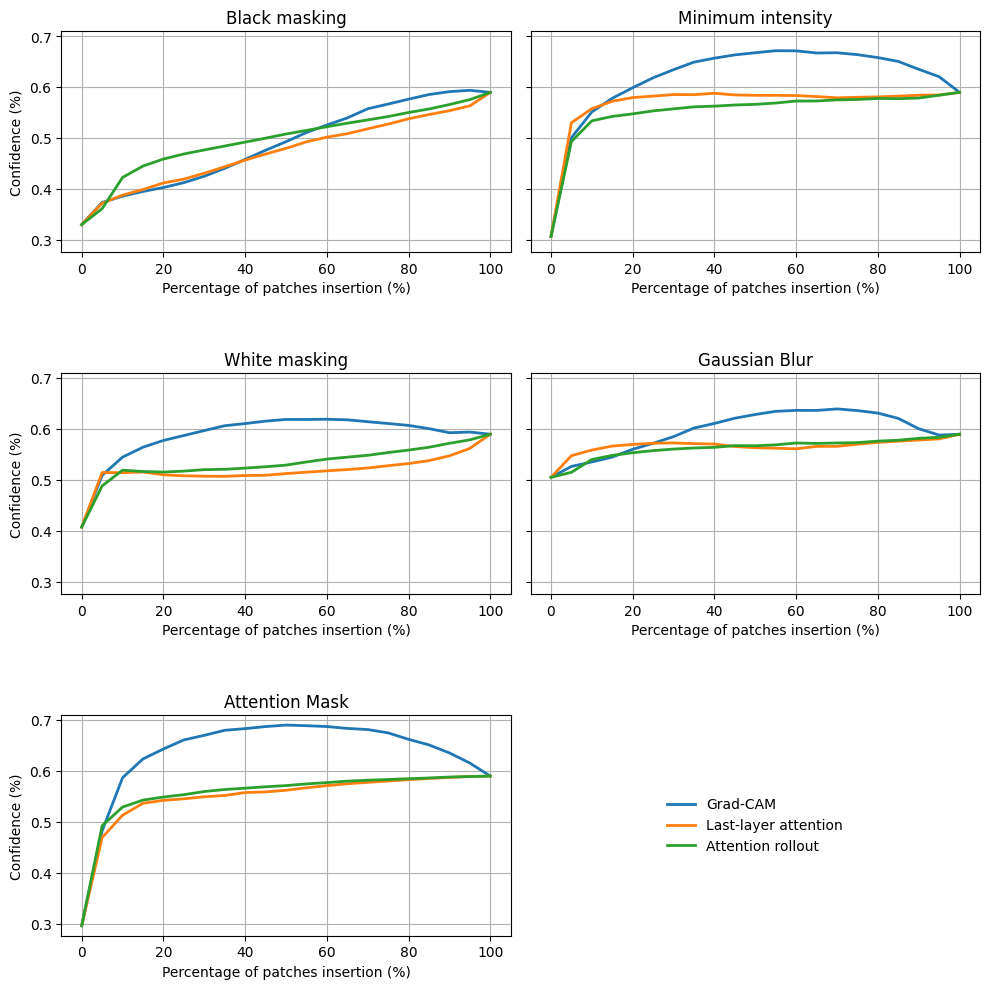

In [8]:
evaluation_metric = "insertion"

OUTPUT_DIR = Path("perturbation_plots")
OUTPUT_DIR.mkdir(exist_ok=True)

# ===== SETUP =====
strategies = list(replacement_strategies.items())
n_strategies = len(strategies)

# Create 3 rows, 2 columns
fig, axes = plt.subplots(3, 2, figsize=(10, 10), sharey=True)

# Flatten axes for easy indexing
axes = axes.flatten()

# ===== LOOP =====
for i, (strategy_key, strategy_name) in enumerate(strategies):
    ax = axes[i]

    for method_key, method_name in xai_methods.items():

        curve_dir = base_path / evaluation_metric / f"{evaluation_metric}_curves" / method_key / strategy_key

        curves = []
        percentages = None

        for f in curve_dir.glob("*.npy"):
            data = np.load(f, allow_pickle=True).item()
            curves.append(data["predicted_confidences"])

            if percentages is None:
                percentages = data["percentages"]

        if len(curves) == 0:
            continue

        curves = np.array(curves)

        # Mean curve
        mean_curve = curves.mean(axis=0)

        ax.plot(percentages*100,
                mean_curve,
                label=method_name,
                color=colors[method_key],
                linewidth=2)
        
        # std_curve = curves.std(axis=0)

        # ax.fill_between(
        #     percentages*100,
        #     mean_curve - std_curve,
        #     mean_curve + std_curve,
        #     color=colors[method_key],
        #     alpha=0.2
        # )

    # Subplot formatting
    ax.set_title(strategy_name)
    ax.set_xlabel(f"Percentage of patches {evaluation_metric} (%)")
    ax.grid(True)

# # ===== REMOVE EMPTY PLOT =====
# for j in range(n_strategies, len(axes)):
#     fig.delaxes(axes[j])

# ===== USE LAST AXIS FOR LEGEND =====
legend_ax = axes[-1]
# Turn off axis
legend_ax.axis("off")
# Get legend handles
handles, labels = axes[0].get_legend_handles_labels()
# Place legend inside this subplot
legend_ax.legend(handles, labels, loc="center", frameon=False)

# ===== SHARED LABEL =====
axes[0].set_ylabel("Confidence (%)")
axes[2].set_ylabel("Confidence (%)")
axes[4].set_ylabel("Confidence (%)")

# # ===== LEGEND =====
# handles, labels = axes[0].get_legend_handles_labels()
# fig.legend(handles, labels, loc="lower right", ncol=3)

# ===== TITLE =====
# fig.suptitle(f"{evaluation_methods[evaluation_metric]} Evaluation (Mean Curves)", fontsize=14)

# plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.tight_layout(h_pad=4)
# plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"{evaluation_metric}_evaluation_curves.jpg", dpi=150)
plt.show()

### Negative

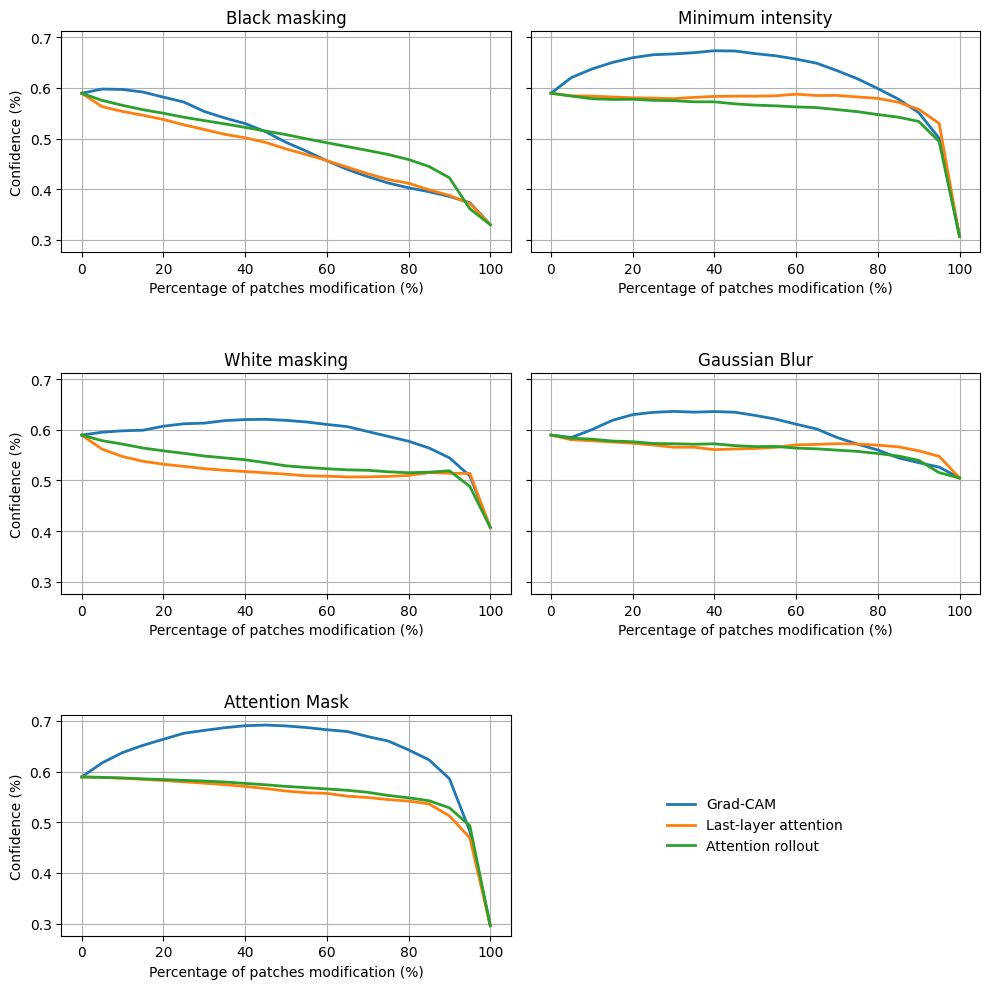

In [9]:
evaluation_metric = "negative"

OUTPUT_DIR = Path("perturbation_plots")
OUTPUT_DIR.mkdir(exist_ok=True)

# ===== SETUP =====
strategies = list(replacement_strategies.items())
n_strategies = len(strategies)

# Create 3 rows, 2 columns
fig, axes = plt.subplots(3, 2, figsize=(10, 10), sharey=True)

# Flatten axes for easy indexing
axes = axes.flatten()

# ===== LOOP =====
for i, (strategy_key, strategy_name) in enumerate(strategies):
    ax = axes[i]

    for method_key, method_name in xai_methods.items():

        curve_dir = base_path / evaluation_metric / f"{evaluation_metric}_curves" / method_key / strategy_key

        curves = []
        percentages = None

        for f in curve_dir.glob("*.npy"):
            data = np.load(f, allow_pickle=True).item()
            curves.append(data["predicted_confidences"])

            if percentages is None:
                percentages = data["percentages"]

        if len(curves) == 0:
            continue

        curves = np.array(curves)

        # Mean curve
        mean_curve = curves.mean(axis=0)

        ax.plot(percentages*100,
                mean_curve,
                label=method_name,
                color=colors[method_key],
                linewidth=2)
        
        # std_curve = curves.std(axis=0)

        # ax.fill_between(
        #     percentages*100,
        #     mean_curve - std_curve,
        #     mean_curve + std_curve,
        #     color=colors[method_key],
        #     alpha=0.2
        # )

    # Subplot formatting
    ax.set_title(strategy_name)
    ax.set_xlabel(f"Percentage of patches modification (%)")
    ax.grid(True)

# # ===== REMOVE EMPTY PLOT =====
# for j in range(n_strategies, len(axes)):
#     fig.delaxes(axes[j])

# ===== USE LAST AXIS FOR LEGEND =====
legend_ax = axes[-1]
# Turn off axis
legend_ax.axis("off")
# Get legend handles
handles, labels = axes[0].get_legend_handles_labels()
# Place legend inside this subplot
legend_ax.legend(handles, labels, loc="center", frameon=False)

# ===== SHARED LABEL =====
axes[0].set_ylabel("Confidence (%)")
axes[2].set_ylabel("Confidence (%)")
axes[4].set_ylabel("Confidence (%)")

# # ===== LEGEND =====
# handles, labels = axes[0].get_legend_handles_labels()
# fig.legend(handles, labels, loc="lower right", ncol=3)

# ===== TITLE =====
# fig.suptitle(f"{evaluation_methods[evaluation_metric]} Evaluation (Mean Curves)", fontsize=14)

# plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.tight_layout(h_pad=4)
# plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"{evaluation_metric}_evaluation_curves.jpg", dpi=150)
plt.show()

#### Drop Curve

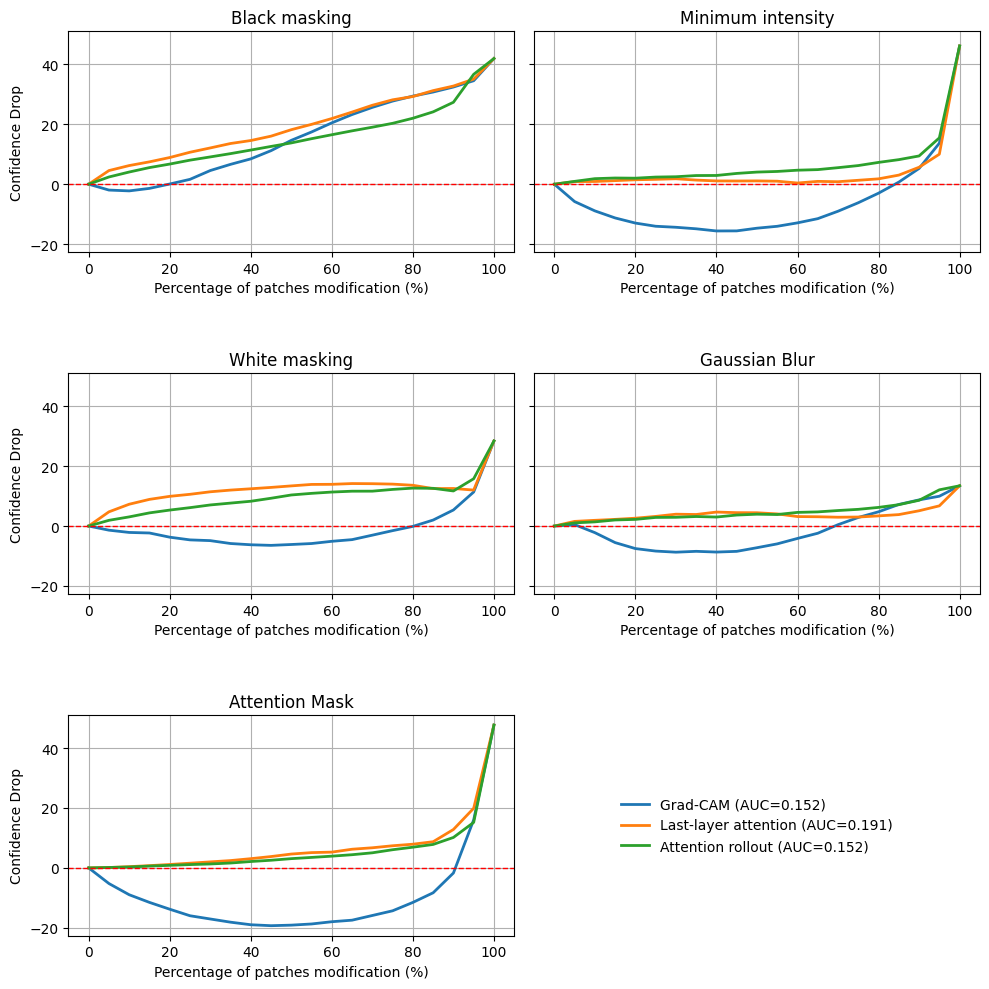


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/conda/lib/python3.11/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/opt/conda/lib/python3.11/site-packages/traitlets/config/application.py", line 1053, in launch_instance
    app.start()
  File "/opt/conda/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 736, in start
    self.io_loop.start()
  File "/opt/conda/lib/python3.11/site-packages/tornado

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/conda/lib/python3.11/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/opt/conda/lib/python3.11/site-packages/traitlets/config/application.py", line 1053, in launch_instance
    app.start()
  File "/opt/conda/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 736, in start
    self.io_loop.start()
  File "/opt/conda/lib/python3.11/site-packages/tornado

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/conda/lib/python3.11/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/opt/conda/lib/python3.11/site-packages/traitlets/config/application.py", line 1053, in launch_instance
    app.start()
  File "/opt/conda/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 736, in start
    self.io_loop.start()
  File "/opt/conda/lib/python3.11/site-packages/tornado

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/conda/lib/python3.11/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/opt/conda/lib/python3.11/site-packages/traitlets/config/application.py", line 1053, in launch_instance
    app.start()
  File "/opt/conda/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 736, in start
    self.io_loop.start()
  File "/opt/conda/lib/python3.11/site-packages/tornado

AttributeError: _ARRAY_API not found

                  method           strategy  mean_auc  std_auc
0               Grad-CAM      Black masking     0.152    0.154
1   Last-layer attention      Black masking     0.191    0.117
2      Attention rollout      Black masking     0.152    0.099
3               Grad-CAM  Minimum intensity    -0.071    0.174
4   Last-layer attention  Minimum intensity     0.030    0.128
5      Attention rollout  Minimum intensity     0.057    0.099
6               Grad-CAM      White masking    -0.015    0.160
7   Last-layer attention      White masking     0.119    0.137
8      Attention rollout      White masking     0.094    0.080
9               Grad-CAM      Gaussian Blur    -0.018    0.182
10  Last-layer attention      Gaussian Blur     0.037    0.137
11     Attention rollout      Gaussian Blur     0.045    0.107
12              Grad-CAM     Attention Mask    -0.107    0.139
13  Last-layer attention     Attention Mask     0.062    0.069
14     Attention rollout     Attention Mask     0.050  

In [10]:
# ===== Negative Perturbation: Drop Curve + AUC =====

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import auc

evaluation_metric = "negative"

OUTPUT_DIR = Path("perturbation_plots")
OUTPUT_DIR.mkdir(exist_ok=True)

strategies = list(replacement_strategies.items())
fig, axes = plt.subplots(3, 2, figsize=(10, 10), sharey=True)
axes = axes.flatten()

# Store AUC results
results = []

for i, (strategy_key, strategy_name) in enumerate(strategies):
    ax = axes[i]

    for method_key, method_name in xai_methods.items():

        curve_dir = base_path / evaluation_metric / f"{evaluation_metric}_curves" / method_key / strategy_key

        curves = []
        percentages = None

        for f in curve_dir.glob("*.npy"):
            data = np.load(f, allow_pickle=True).item()
            curves.append(data["predicted_confidences"])

            if percentages is None:
                percentages = data["percentages"]

        if len(curves) == 0:
            continue

        curves = np.array(curves)  # [N, T]

        # ===== DROP CURVE =====
        c0 = curves[:, 0:1]  # initial confidence
        drop_curves = (c0 - curves) / (c0 + 1e-8)

        # ===== MEAN CURVE =====
        mean_curve = drop_curves.mean(axis=0)

        # ===== AUC =====
        auc_scores = [auc(percentages, curve) for curve in drop_curves]
        mean_auc = np.mean(auc_scores)
        std_auc = np.std(auc_scores)

        results.append({
            "method": method_name,
            "strategy": strategy_name,
            "mean_auc": round(mean_auc, 3),
            "std_auc": round(std_auc, 3)
        })

        # ===== PLOT =====
        ax.plot(percentages * 100,
                mean_curve*100,
                label=f"{method_name} (AUC={mean_auc:.3f})",
                color=colors[method_key],
                linewidth=2)

    ax.axhline(y=0, linestyle="--", linewidth=1, color="red")
    ax.set_title(strategy_name)
    ax.set_xlabel("Percentage of patches modification (%)")
    ax.grid(True)

# ===== LEGEND PANEL =====
legend_ax = axes[-1]
legend_ax.axis("off")
handles, labels = axes[0].get_legend_handles_labels()
legend_ax.legend(handles, labels, loc="center", frameon=False)

# ===== Y LABEL =====
axes[0].set_ylabel("Confidence Drop")
axes[2].set_ylabel("Confidence Drop")
axes[4].set_ylabel("Confidence Drop")

plt.tight_layout(h_pad=4)
plt.savefig(OUTPUT_DIR / f"{evaluation_metric}_drop_curves_normalized.jpg", dpi=150)
plt.show()

# ===== PRINT RESULTS =====
import pandas as pd
df_results = pd.DataFrame(results)
print(df_results)

## Case Analysis

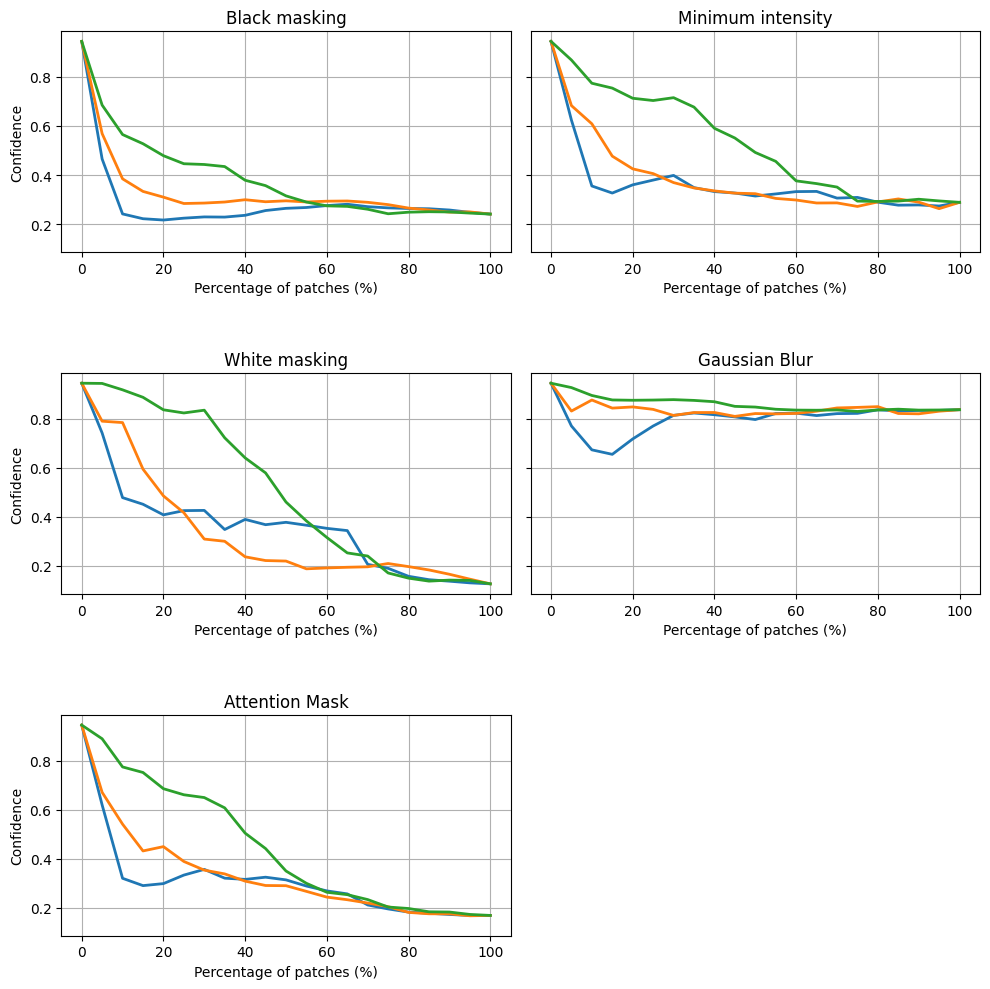

In [11]:
evaluation_metric = "deletion"  # or "insertion" / "negative"
UID = "ODELIA_TRICKS_0067_1_left"

strategies = list(replacement_strategies.items())

fig, axes = plt.subplots(3, 2, figsize=(10, 10), sharey=True)
axes = axes.flatten()

for i, (strategy_key, strategy_name) in enumerate(strategies):
    ax = axes[i]

    for method_key, method_name in xai_methods.items():

        curve_dir = base_path / evaluation_metric / f"{evaluation_metric}_curves" / method_key / strategy_key
        
        # Find file for this UID
        file_path = curve_dir / f"{UID}_curve_{strategy_key}.npy"

        if not file_path.exists():
            continue

        data = np.load(file_path, allow_pickle=True).item()
        curve = data["predicted_confidences"]
        percentages = data["percentages"]

        ax.plot(
            percentages * 100,
            curve,
            label=method_name,
            color=colors[method_key],
            linewidth=2
        )

    # Formatting
    ax.set_title(strategy_name)
    ax.set_xlabel("Percentage of patches (%)")
    ax.grid(True)

# Remove unused subplot if needed
for j in range(len(strategies), len(axes)):
    fig.delaxes(axes[j])

# Legend in last panel
legend_ax = axes[-1]
legend_ax.axis("off")
handles, labels = axes[0].get_legend_handles_labels()
legend_ax.legend(handles, labels, loc="center", frameon=False)

# Y-label
axes[0].set_ylabel("Confidence")
axes[2].set_ylabel("Confidence")
axes[4].set_ylabel("Confidence")

plt.tight_layout(h_pad=4)
plt.show()

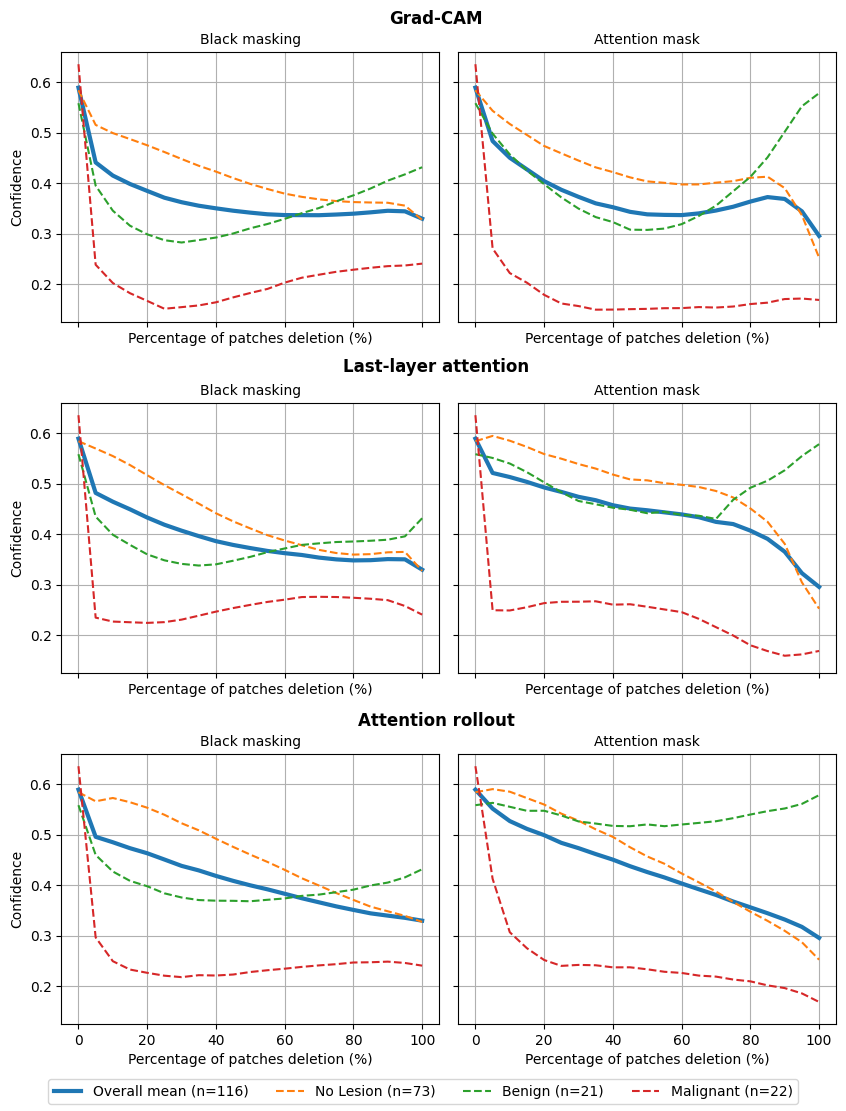

In [12]:

# =========================
# Settings
# =========================
evaluation_metric = "deletion"

selected_strategies = {
    "black-5": "Black masking",
    "attention_mask": "Attention mask"
}

# # Class colors (class-wise mean curves)
# class_colors = {
#     0: "black",
#     1: "orange",
#     2: "purple"
# }

class_names = {
    0: "No Lesion",
    1: "Benign",
    2: "Malignant"
}


OUTPUT_DIR = Path("perturbation_plots")
OUTPUT_DIR.mkdir(exist_ok=True)

# =========================
# Figure setup
# =========================
fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(10, 12),
    sharex=True,
    sharey=True
)

xai_list = list(xai_methods.items())
strategy_list = list(selected_strategies.items())

# =========================
# Main loop
# =========================
for row_idx, (method_key, method_name) in enumerate(xai_list):

    for col_idx, (strategy_key, strategy_name) in enumerate(strategy_list):

        ax = axes[row_idx, col_idx]

        curve_dir = (
            base_path
            / evaluation_metric
            / f"{evaluation_metric}_curves"
            / method_key
            / strategy_key
        )

        all_curves = []
        class_curves = {0: [], 1: [], 2: []}
        percentages = None

        # Load all curves
        for f in curve_dir.glob("*.npy"):
            data = np.load(f, allow_pickle=True).item()

            curve = data["predicted_confidences"]
            pred_class = data["predicted_class"]

            all_curves.append(curve)
            class_curves[pred_class].append(curve)

            if percentages is None:
                percentages = data["percentages"]

        if len(all_curves) == 0:
            continue

        all_curves = np.array(all_curves)

        # =========================
        # Overall mean curve
        # =========================
        overall_mean = all_curves.mean(axis=0)

        ax.plot(
            percentages * 100,
            overall_mean,
            linewidth=3,
            label=f"Overall mean (n={len(all_curves)})"
        )

        # =========================
        # Class-wise mean curves
        # =========================
        for cls in [0, 1, 2]:
            if len(class_curves[cls]) == 0:
                continue

            class_mean = np.mean(class_curves[cls], axis=0)
            n_samples = len(class_curves[cls])

            ax.plot(
                percentages * 100,
                class_mean,
                linestyle="--",
                # linewidth=2,
                # color=class_colors[cls],
                label=f"{class_names[cls]} (n={n_samples})"
            )
        ax.set_xlabel("Percentage of patches deletion (%)")
        ax.set_title(strategy_name, fontsize=10)
        ax.grid(True)

# =========================
# Shared axis labels
# =========================
for row_idx in range(3):
    axes[row_idx, 0].set_ylabel("Confidence")




fig.text(
    0.5,
    0.915,
    "Grad-CAM",
    ha="center",
    va="top",
    fontsize=12,
    weight="bold"
)


fig.text(
    0.5,
    0.625,
    "Last-layer attention",
    ha="center",
    va="top",
    fontsize=12,
    weight="bold"
)

fig.text(
    0.5,
    0.33,
    "Attention rollout",
    ha="center",
    va="top",
    fontsize=12,
    weight="bold"
)

# =========================
# Global legend
# =========================
handles, labels = axes[0, 0].get_legend_handles_labels()

# Remove duplicate labels
unique = dict(zip(labels, handles))

fig.legend(
    unique.values(),
    unique.keys(),
    loc="lower center",
    ncol=4,
    frameon=True
)

# Increase vertical space between subplot rows
fig.subplots_adjust(
    # top=0.85,      # leave space for legend
    hspace=0.3,   # space between rows (important)
    wspace=0.05,   # space between columns
    bottom=0.07    # leave space for legend
)

plt.savefig(
    OUTPUT_DIR / "deletion_classwise_case_analysis.jpg",
    dpi=150,
    bbox_inches="tight"
)

plt.show()
plt.close()

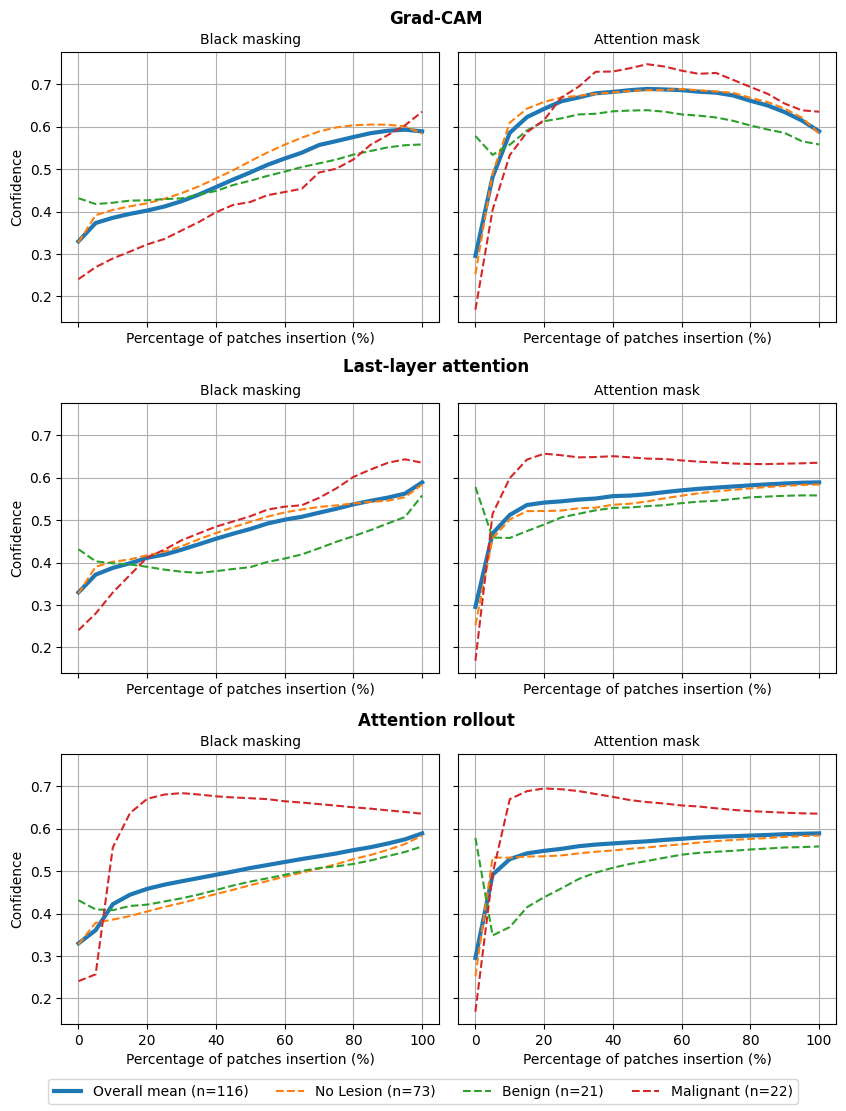

In [13]:

# =========================
# Settings
# =========================
evaluation_metric = "insertion"

selected_strategies = {
    "black-5": "Black masking",
    "attention_mask": "Attention mask"
}

# # Class colors (class-wise mean curves)
# class_colors = {
#     0: "black",
#     1: "orange",
#     2: "purple"
# }

class_names = {
    0: "No Lesion",
    1: "Benign",
    2: "Malignant"
}


OUTPUT_DIR = Path("perturbation_plots")
OUTPUT_DIR.mkdir(exist_ok=True)

# =========================
# Figure setup
# =========================
fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(10, 12),
    sharex=True,
    sharey=True
)

xai_list = list(xai_methods.items())
strategy_list = list(selected_strategies.items())

# =========================
# Main loop
# =========================
for row_idx, (method_key, method_name) in enumerate(xai_list):

    for col_idx, (strategy_key, strategy_name) in enumerate(strategy_list):

        ax = axes[row_idx, col_idx]

        curve_dir = (
            base_path
            / evaluation_metric
            / f"{evaluation_metric}_curves"
            / method_key
            / strategy_key
        )

        all_curves = []
        class_curves = {0: [], 1: [], 2: []}
        percentages = None

        # Load all curves
        for f in curve_dir.glob("*.npy"):
            data = np.load(f, allow_pickle=True).item()

            curve = data["predicted_confidences"]
            pred_class = data["predicted_class"]

            all_curves.append(curve)
            class_curves[pred_class].append(curve)

            if percentages is None:
                percentages = data["percentages"]

        if len(all_curves) == 0:
            continue

        all_curves = np.array(all_curves)

        # =========================
        # Overall mean curve
        # =========================
        overall_mean = all_curves.mean(axis=0)

        ax.plot(
            percentages * 100,
            overall_mean,
            linewidth=3,
            label=f"Overall mean (n={len(all_curves)})"
        )

        # =========================
        # Class-wise mean curves
        # =========================
        for cls in [0, 1, 2]:
            if len(class_curves[cls]) == 0:
                continue

            class_mean = np.mean(class_curves[cls], axis=0)
            n_samples = len(class_curves[cls])

            ax.plot(
                percentages * 100,
                class_mean,
                linestyle="--",
                # linewidth=2,
                # color=class_colors[cls],
                label=f"{class_names[cls]} (n={n_samples})"
            )
        ax.set_xlabel("Percentage of patches insertion (%)")
        ax.set_title(strategy_name, fontsize=10)
        ax.grid(True)

# =========================
# Shared axis labels
# =========================
for row_idx in range(3):
    axes[row_idx, 0].set_ylabel("Confidence")




fig.text(
    0.5,
    0.915,
    "Grad-CAM",
    ha="center",
    va="top",
    fontsize=12,
    weight="bold"
)


fig.text(
    0.5,
    0.625,
    "Last-layer attention",
    ha="center",
    va="top",
    fontsize=12,
    weight="bold"
)

fig.text(
    0.5,
    0.33,
    "Attention rollout",
    ha="center",
    va="top",
    fontsize=12,
    weight="bold"
)

# =========================
# Global legend
# =========================
handles, labels = axes[0, 0].get_legend_handles_labels()

# Remove duplicate labels
unique = dict(zip(labels, handles))

fig.legend(
    unique.values(),
    unique.keys(),
    loc="lower center",
    ncol=4,
    frameon=True
)

# Increase vertical space between subplot rows
fig.subplots_adjust(
    # top=0.85,      # leave space for legend
    hspace=0.3,   # space between rows (important)
    wspace=0.05,   # space between columns
    bottom=0.07    # leave space for legend
)

plt.savefig(
    OUTPUT_DIR / "insertion_classwise_case_analysis.jpg",
    dpi=150,
    bbox_inches="tight"
)

plt.show()
plt.close()

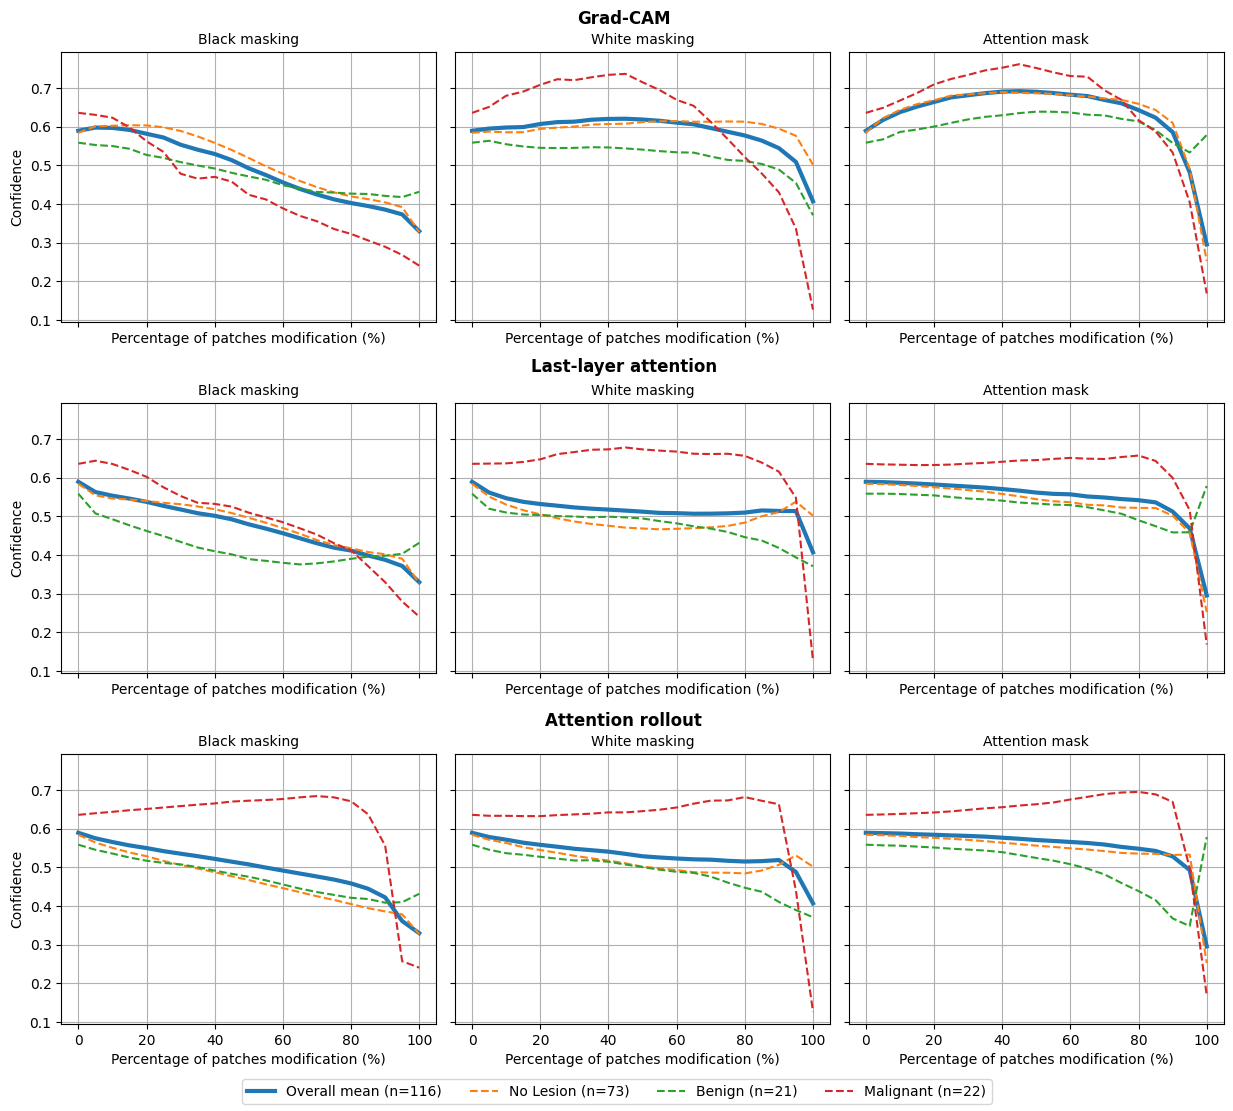

In [18]:

# =========================
# Settings
# =========================
evaluation_metric = "negative"  

selected_strategies = {
    "black-5": "Black masking",
    "white-5": "White masking",
    "attention_mask": "Attention mask"
}

# # Class colors (class-wise mean curves)
# class_colors = {
#     0: "black",
#     1: "orange",
#     2: "purple"
# }

class_names = {
    0: "No Lesion",
    1: "Benign",
    2: "Malignant"
}


OUTPUT_DIR = Path("perturbation_plots")
OUTPUT_DIR.mkdir(exist_ok=True)

# =========================
# Figure setup
# =========================
fig, axes = plt.subplots(
    nrows=3,
    ncols=3,
    figsize=(15, 12),
    sharex=True,
    sharey=True
)

xai_list = list(xai_methods.items())
strategy_list = list(selected_strategies.items())

# =========================
# Main loop
# =========================
for row_idx, (method_key, method_name) in enumerate(xai_list):

    for col_idx, (strategy_key, strategy_name) in enumerate(strategy_list):

        ax = axes[row_idx, col_idx]

        curve_dir = (
            base_path
            / evaluation_metric
            / f"{evaluation_metric}_curves"
            / method_key
            / strategy_key
        )

        all_curves = []
        class_curves = {0: [], 1: [], 2: []}
        percentages = None

        # Load all curves
        for f in curve_dir.glob("*.npy"):
            data = np.load(f, allow_pickle=True).item()

            curve = data["predicted_confidences"]
            pred_class = data["predicted_class"]

            all_curves.append(curve)
            class_curves[pred_class].append(curve)

            if percentages is None:
                percentages = data["percentages"]

        if len(all_curves) == 0:
            continue

        all_curves = np.array(all_curves)

        # =========================
        # Overall mean curve
        # =========================
        overall_mean = all_curves.mean(axis=0)

        ax.plot(
            percentages * 100,
            overall_mean,
            linewidth=3,
            label=f"Overall mean (n={len(all_curves)})"
        )

        # =========================
        # Class-wise mean curves
        # =========================
        for cls in [0, 1, 2]:
            if len(class_curves[cls]) == 0:
                continue

            class_mean = np.mean(class_curves[cls], axis=0)
            n_samples = len(class_curves[cls])

            ax.plot(
                percentages * 100,
                class_mean,
                linestyle="--",
                # linewidth=2,
                # color=class_colors[cls],
                label=f"{class_names[cls]} (n={n_samples})"
            )
        ax.set_xlabel("Percentage of patches modification (%)")
        ax.set_title(strategy_name, fontsize=10)
        ax.grid(True)

# =========================
# Shared axis labels
# =========================
for row_idx in range(3):
    axes[row_idx, 0].set_ylabel("Confidence")




fig.text(
    0.5,
    0.915,
    "Grad-CAM",
    ha="center",
    va="top",
    fontsize=12,
    weight="bold"
)


fig.text(
    0.5,
    0.625,
    "Last-layer attention",
    ha="center",
    va="top",
    fontsize=12,
    weight="bold"
)

fig.text(
    0.5,
    0.33,
    "Attention rollout",
    ha="center",
    va="top",
    fontsize=12,
    weight="bold"
)

# =========================
# Global legend
# =========================
handles, labels = axes[0, 0].get_legend_handles_labels()

# Remove duplicate labels
unique = dict(zip(labels, handles))

fig.legend(
    unique.values(),
    unique.keys(),
    loc="lower center",
    ncol=4,
    frameon=True
)

# Increase vertical space between subplot rows
fig.subplots_adjust(
    # top=0.85,      # leave space for legend
    hspace=0.3,   # space between rows (important)
    wspace=0.05,   # space between columns
    bottom=0.07    # leave space for legend
)

plt.savefig(
    OUTPUT_DIR / "negative_classwise_case_analysis.jpg",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

#### Only correct classified

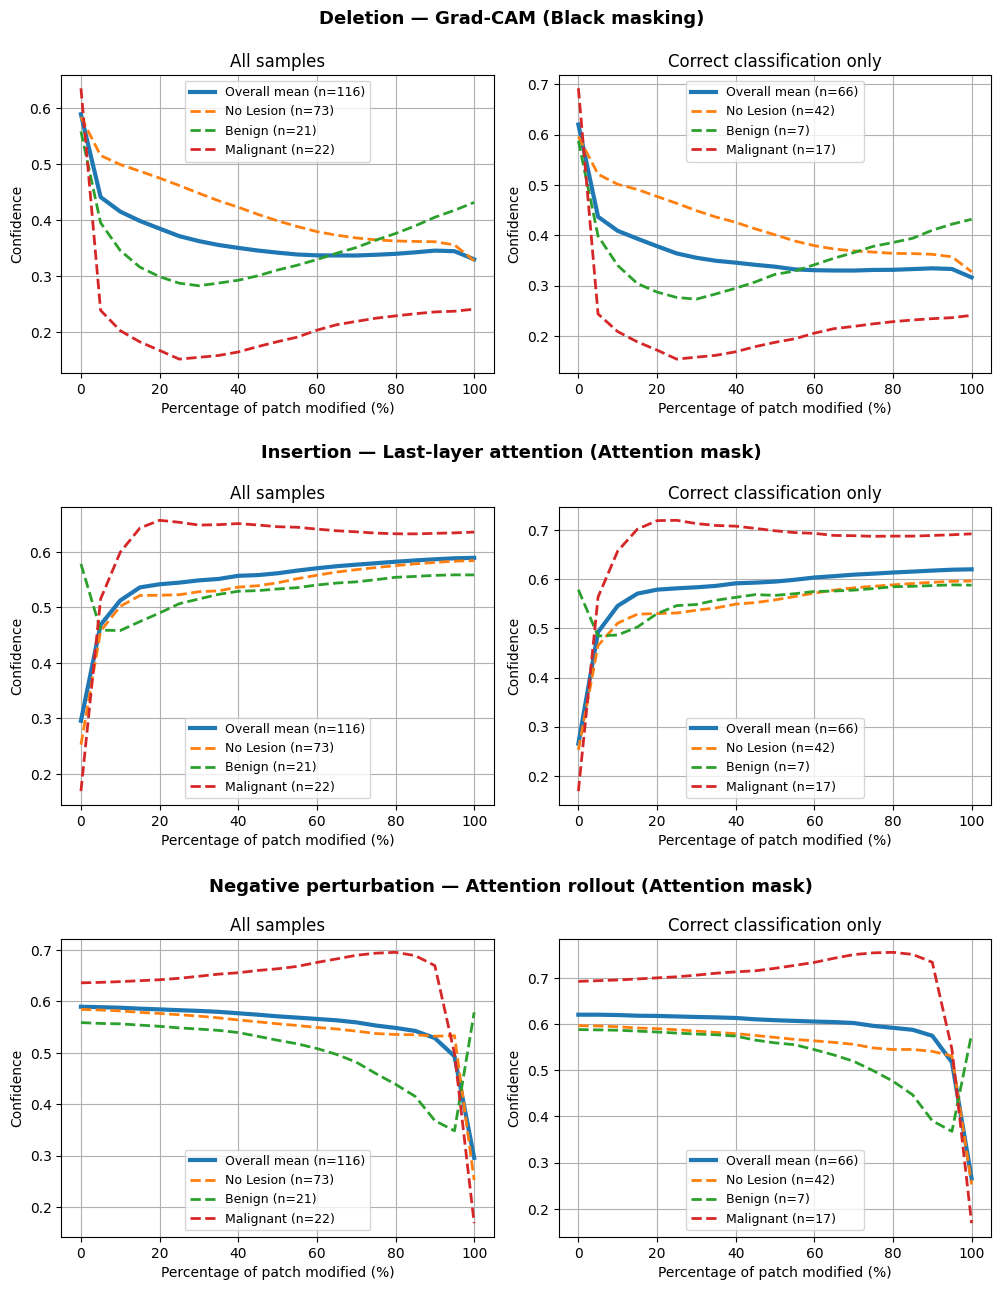

In [28]:
import json

# ==========================================
# Load correct prediction UIDs
# ==========================================
with open(
    "/home/jovyan/work/MST/scripts/Jupyter_notebook/Confusion Matrix/v3_correct_full.json",
    "r"
) as f:
    correct_data = json.load(f)

# Convert to set for fast lookup
correct_uid_set = set()

for cls in correct_data.keys():
    for item in correct_data[cls]:
        correct_uid_set.add(item["UID"])

# ==========================================
# Selected experiments
# ==========================================
selected_experiments = [
    {
        "evaluation_metric": "deletion",
        "method_key": "gradcam",
        "method_name": "Grad-CAM",
        "strategy_key": "black-5",
        "strategy_name": "Black masking"
    },
    {
        "evaluation_metric": "insertion",
        "method_key": "last_layer",
        "method_name": "Last-layer attention",
        "strategy_key": "attention_mask",
        "strategy_name": "Attention mask"
    },
    {
        "evaluation_metric": "negative",
        "method_key": "slice_weighted_rollout",
        "method_name": "Attention rollout",
        "strategy_key": "attention_mask",
        "strategy_name": "Attention mask"
    }
]

# ==========================================
# Plot settings
# ==========================================
OUTPUT_DIR = Path("perturbation_plots")
OUTPUT_DIR.mkdir(exist_ok=True)

class_names = {
    0: "No Lesion",
    1: "Benign",
    2: "Malignant"
}

class_colors = {
    0: "tab:orange",
    1: "tab:green",
    2: "tab:red"
}

fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(12, 14),
    sharex=False,
    sharey=False
)

# ==========================================
# Main loop
# ==========================================
for row_idx, exp in enumerate(selected_experiments):

    curve_dir = (
        base_path
        / exp["evaluation_metric"]
        / f"{exp['evaluation_metric']}_curves"
        / exp["method_key"]
        / exp["strategy_key"]
    )

    all_curves_all = []
    all_curves_correct = []

    class_curves_all = {0: [], 1: [], 2: []}
    class_curves_correct = {0: [], 1: [], 2: []}

    percentages = None

    for f in curve_dir.glob("*.npy"):

        data = np.load(f, allow_pickle=True).item()

        uid = f.name.split("_curve_")[0]
        curve = data["predicted_confidences"]
        pred_class = data["predicted_class"]

        if percentages is None:
            percentages = data["percentages"]

        # ---------- All samples ----------
        all_curves_all.append(curve)
        class_curves_all[pred_class].append(curve)

        # ---------- Correct only ----------
        if uid in correct_uid_set:
            all_curves_correct.append(curve)
            class_curves_correct[pred_class].append(curve)

    plot_data = [
        ("All samples", all_curves_all, class_curves_all),
        ("Correct classification only", all_curves_correct, class_curves_correct)
    ]

    for col_idx, (title, overall_curves, class_curves) in enumerate(plot_data):

        ax = axes[row_idx, col_idx]

        overall_curves = np.array(overall_curves)

        # Overall mean
        overall_mean = overall_curves.mean(axis=0)

        ax.plot(
            percentages * 100,
            overall_mean,
            linewidth=3,
            label=f"Overall mean (n={len(overall_curves)})"
        )

        # Class-wise means
        for cls in [0, 1, 2]:

            if len(class_curves[cls]) == 0:
                continue

            class_mean = np.mean(class_curves[cls], axis=0)

            ax.plot(
                percentages * 100,
                class_mean,
                linestyle="--",
                linewidth=2,
                color=class_colors[cls],
                label=f"{class_names[cls]} (n={len(class_curves[cls])})"
            )

        ax.set_title(title)
        ax.set_xlabel(
            "Percentage of patch modified (%)"
        )
        ax.set_ylabel("Confidence")
        ax.grid(True)

    # Row title
    fig.text(
        0.5,
        0.92 - row_idx * 0.31,
        f"{exp['evaluation_metric'].capitalize()} — {exp['method_name']} ({exp['strategy_name']})" if exp["evaluation_metric"] in ["deletion", "insertion"] else "Negative perturbation — " + \
        f"{exp['method_name']} ({exp['strategy_name']})",
        ha="center",
        va="center",
        fontsize=13,
        fontweight="bold"
    )

# ==========================================
# Legend
# ==========================================
# ==========================================
# Local legends (per subplot)
# ==========================================
for row_idx in range(3):
    for col_idx in range(2):

        ax = axes[row_idx, col_idx]

        handles, labels = ax.get_legend_handles_labels()

        # remove duplicates inside subplot
        unique = dict(zip(labels, handles))

        ax.legend(
            unique.values(),
            unique.keys(),
            loc="upper center" if ax == axes[0, 0] or ax == axes[0, 1] else "lower center",
            fontsize=9,
            frameon=True
        )
# ==========================================
# Layout
# ==========================================
fig.subplots_adjust(
    hspace=0.45,
    wspace=0.15,
    bottom=0.05
)

plt.savefig(
    OUTPUT_DIR / "all_vs_correct_classwise_comparison.jpg",
    dpi=150,
    bbox_inches="tight"
)

plt.show()
plt.close()

## Modification Method Analysis

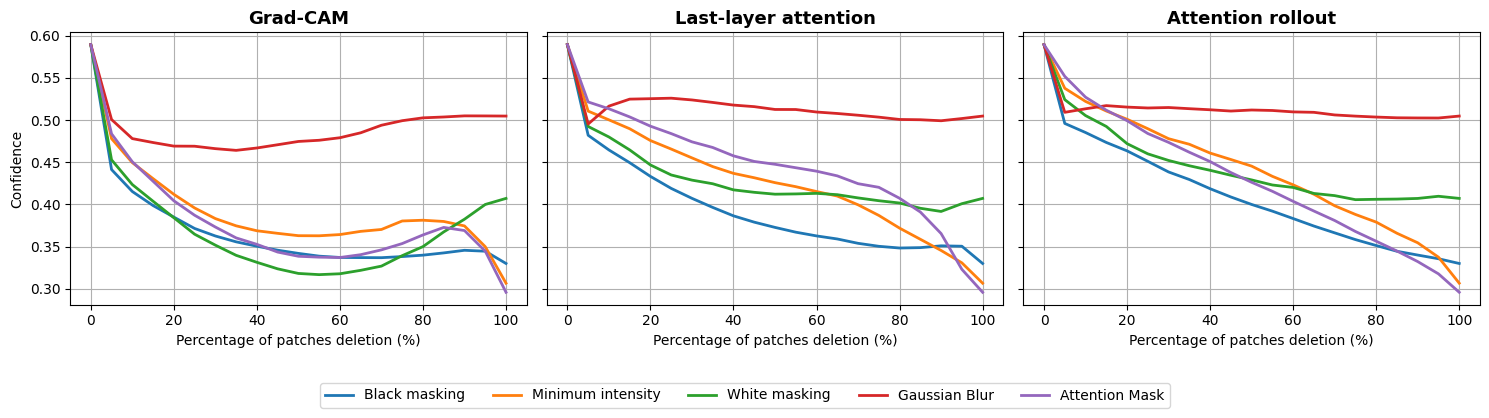

In [40]:
evaluation_metric = "deletion"

OUTPUT_DIR = Path("perturbation_plots")
OUTPUT_DIR.mkdir(exist_ok=True)

# =========================
# Figure setup
# =========================
fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(15, 4),
    sharex=True,
    sharey=True
)

xai_list = list(xai_methods.items())
strategy_list = list(replacement_strategies.items())

# =========================
# Main loop
# =========================
for row_idx, (method_key, method_name) in enumerate(xai_list):

    ax = axes[row_idx]

    for strategy_key, strategy_name in strategy_list:

        curve_dir = (
            base_path
            / evaluation_metric
            / f"{evaluation_metric}_curves"
            / method_key
            / strategy_key
        )

        curves = []
        percentages = None

        for f in curve_dir.glob("*.npy"):

            data = np.load(f, allow_pickle=True).item()

            curves.append(data["predicted_confidences"])

            if percentages is None:
                percentages = data["percentages"]

        if len(curves) == 0:
            continue

        curves = np.array(curves)

        mean_curve = curves.mean(axis=0)

        ax.plot(
            percentages * 100,
            mean_curve,
            label=strategy_name,
            linewidth=2
        )

    # Plot formatting
    ax.set_title(
        method_name,
        fontsize=13,
        fontweight="bold"
    )
    ax.set_xlabel(
        f"Percentage of patches {evaluation_metric} (%)"
    )
    ax.grid(True)

# Shared Y label
axes[0].set_ylabel("Confidence")

# =========================
# Global legend
# =========================
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=5,
    frameon=True,
    bbox_to_anchor=(0.5, -0.05)
)

# Layout (reserve space for legend)
plt.tight_layout(
    rect=[0, 0.08, 1, 1]
)

# Save
plt.savefig(
    OUTPUT_DIR / f"{evaluation_metric}_strategy_comparison_per_xai.jpg",
    dpi=150,
    bbox_inches="tight"
)

plt.show()
plt.close()

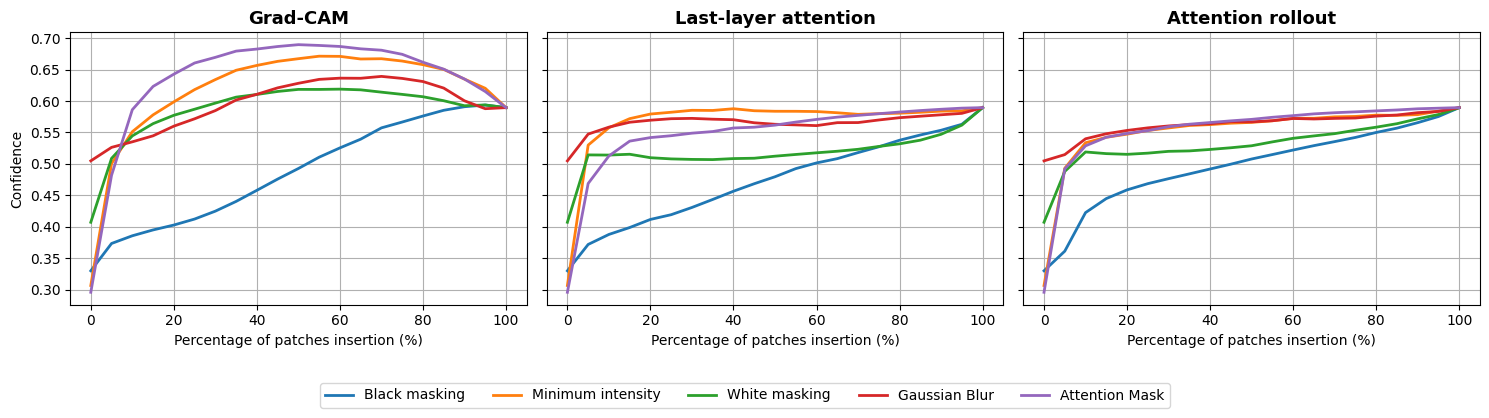

In [41]:
evaluation_metric = "insertion"

OUTPUT_DIR = Path("perturbation_plots")
OUTPUT_DIR.mkdir(exist_ok=True)

# =========================
# Figure setup
# =========================
fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(15, 4),
    sharex=True,
    sharey=True
)

xai_list = list(xai_methods.items())
strategy_list = list(replacement_strategies.items())

# =========================
# Main loop
# =========================
for row_idx, (method_key, method_name) in enumerate(xai_list):

    ax = axes[row_idx]

    for strategy_key, strategy_name in strategy_list:

        curve_dir = (
            base_path
            / evaluation_metric
            / f"{evaluation_metric}_curves"
            / method_key
            / strategy_key
        )

        curves = []
        percentages = None

        for f in curve_dir.glob("*.npy"):

            data = np.load(f, allow_pickle=True).item()

            curves.append(data["predicted_confidences"])

            if percentages is None:
                percentages = data["percentages"]

        if len(curves) == 0:
            continue

        curves = np.array(curves)

        mean_curve = curves.mean(axis=0)

        ax.plot(
            percentages * 100,
            mean_curve,
            label=strategy_name,
            linewidth=2
        )

    # Plot formatting
    ax.set_title(
        method_name,
        fontsize=13,
        fontweight="bold"
    )
    ax.set_xlabel(
        f"Percentage of patches {evaluation_metric} (%)"
    )
    ax.grid(True)

# Shared Y label
axes[0].set_ylabel("Confidence")

# =========================
# Global legend
# =========================
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=5,
    frameon=True,
    bbox_to_anchor=(0.5, -0.05)
)

# Layout (reserve space for legend)
plt.tight_layout(
    rect=[0, 0.08, 1, 1]
)

# Save
plt.savefig(
    OUTPUT_DIR / f"{evaluation_metric}_strategy_comparison_per_xai.jpg",
    dpi=150,
    bbox_inches="tight"
)

plt.show()
plt.close()

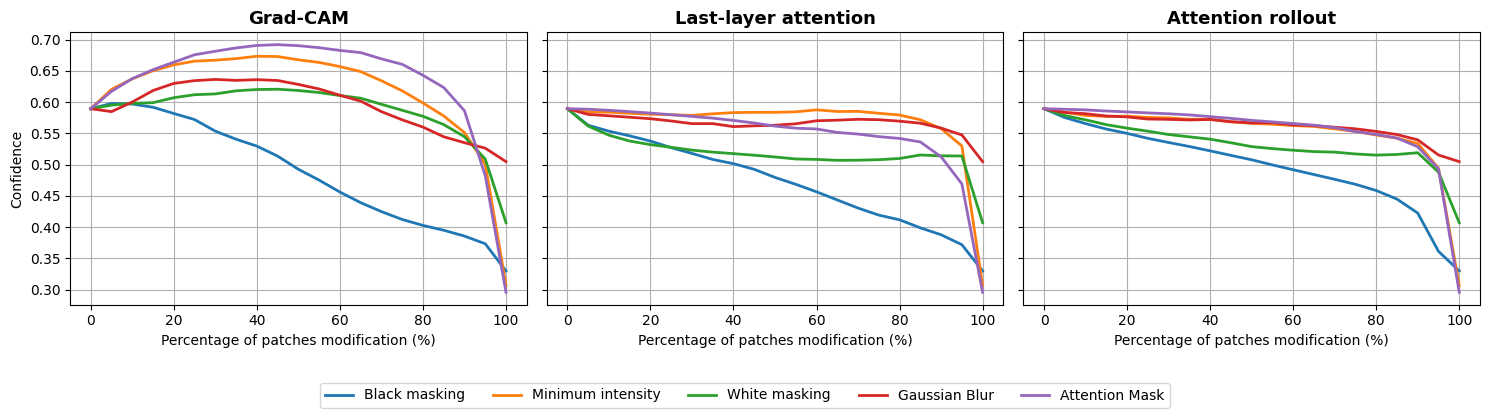

In [43]:
evaluation_metric = "negative"

OUTPUT_DIR = Path("perturbation_plots")
OUTPUT_DIR.mkdir(exist_ok=True)

# =========================
# Figure setup
# =========================
fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(15, 4),
    sharex=True,
    sharey=True
)

xai_list = list(xai_methods.items())
strategy_list = list(replacement_strategies.items())

# =========================
# Main loop
# =========================
for row_idx, (method_key, method_name) in enumerate(xai_list):

    ax = axes[row_idx]

    for strategy_key, strategy_name in strategy_list:

        curve_dir = (
            base_path
            / evaluation_metric
            / f"{evaluation_metric}_curves"
            / method_key
            / strategy_key
        )

        curves = []
        percentages = None

        for f in curve_dir.glob("*.npy"):

            data = np.load(f, allow_pickle=True).item()

            curves.append(data["predicted_confidences"])

            if percentages is None:
                percentages = data["percentages"]

        if len(curves) == 0:
            continue

        curves = np.array(curves)

        mean_curve = curves.mean(axis=0)

        ax.plot(
            percentages * 100,
            mean_curve,
            label=strategy_name,
            linewidth=2
        )

    # Plot formatting
    ax.set_title(
        method_name,
        fontsize=13,
        fontweight="bold"
    )
    ax.set_xlabel(
        f"Percentage of patches modification (%)"
    )
    ax.grid(True)

# Shared Y label
axes[0].set_ylabel("Confidence")

# =========================
# Global legend
# =========================
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=5,
    frameon=True,
    bbox_to_anchor=(0.5, -0.05)
)

# Layout (reserve space for legend)
plt.tight_layout(
    rect=[0, 0.08, 1, 1]
)

# Save
plt.savefig(
    OUTPUT_DIR / f"{evaluation_metric}_strategy_comparison_per_xai.jpg",
    dpi=150,
    bbox_inches="tight"
)

plt.show()
plt.close()